In [1]:
import torch

def print_gpu_available_information():
    print("Number of GPU: ", torch.cuda.device_count())
    print("GPU Name: ", torch.cuda.get_device_name())

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)

print_gpu_available_information()

Number of GPU:  1
GPU Name:  NVIDIA GeForce RTX 3080 Ti
Using device: cuda


## Part 1: EDA 
Exploring and cleaning datasets
Objective: To save a cleaned dataset for training process.

In [2]:
from eda_utils import load_and_concatenate_datasets, inspect_missing_and_constant

# Folder and filenames
folder_path = 'datasets'
filenames = ['metasploitable-2.csv', 'OVS.csv', 'Normal_data.csv']

# Load and inspect
df_raw = load_and_concatenate_datasets(folder_path, filenames)
summary = inspect_missing_and_constant(df_raw)

# Print outputs
print("Columns with NaNs:")
print(summary['nan_count'][summary['nan_count'] > 0])

print("\nColumns with Infs:")
print(summary['inf_count'][summary['inf_count'] > 0])

print(f"\nConstant Columns ({len(summary['constant_columns'])}):")
print(summary['constant_columns'])

Loaded metasploitable-2.csv with shape (136743, 84)
Loaded OVS.csv with shape (138722, 84)
Loaded OVS.csv with shape (138722, 84)
Loaded Normal_data.csv with shape (68424, 84)
Loaded Normal_data.csv with shape (68424, 84)
Columns with NaNs:
Series([], dtype: int64)

Columns with Infs:
Series([], dtype: int64)

Constant Columns (12):
['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']
Columns with NaNs:
Series([], dtype: int64)

Columns with Infs:
Series([], dtype: int64)

Constant Columns (12):
['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [3]:
df_cleaned = df_raw.drop(columns=summary['constant_columns'])
print(f"After dropping constant columns: {df_cleaned.shape}")

After dropping constant columns: (343889, 72)


> Number of Columns: 84 - 12 = 72 (checked)

In [4]:
from eda_utils import check_class_distribution

check_class_distribution(df_cleaned)

Class Distribution:
Label
Probe         98129
DDoS          73529
Normal        68424
DoS           53616
DDoS          48413
BFA            1405
Web-Attack      192
BOTNET          164
U2R              17
Name: count, dtype: int64

Percentage:
Label
Probe         28.54
DDoS          21.38
Normal        19.90
DoS           15.59
DDoS          14.08
BFA            0.41
Web-Attack     0.06
BOTNET         0.05
U2R            0.00
Name: count, dtype: float64


> ! Class imbalance, need generate synthetic data later

In [6]:
from eda_utils import get_highly_correlated_pairs
# Call the function (exclude label first if needed)
df_corr_input = df_cleaned.drop(columns=['Label']) if 'Label' in df_cleaned.columns else df_cleaned.copy()
high_corr_pairs, corr_matrix = get_highly_correlated_pairs(df_corr_input)

# Display top correlated feature pairs
high_corr_pairs.head(20)

,Feature 1,Feature 2,Correlation
870,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.000000
306,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000
655,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.000000
369,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000
1629,Bwd PSH Flags,PSH Flag Cnt,1.000000
1664,Bwd URG Flags,URG Flag Cnt,1.000000
428,TotLen Fwd Pkts,Subflow Fwd Byts,0.999999
489,TotLen Bwd Pkts,Subflow Bwd Byts,0.999998
1174,Flow IAT Max,Idle Max,0.998387
1005,Flow Pkts/s,Bwd Pkts/s,0.998157


> we can try to remove the high correlation pairs with threshold `0.99`

In [7]:
from eda_utils import drop_highly_correlated

df_cleaned, dropped_cols = drop_highly_correlated(df_cleaned, corr_matrix, threshold=0.99)

print(f"Dropped {len(dropped_cols)} highly correlated features:")
for col in dropped_cols:
    print(f" - {col}")

del dropped_cols, corr_matrix
print(f"\nNew shape: {df_cleaned.shape}")

Dropped 15 highly correlated features:
 - Bwd IAT Max
 - Bwd Header Len
 - Bwd Pkts/s
 - PSH Flag Cnt
 - URG Flag Cnt
 - Pkt Size Avg
 - Fwd Seg Size Avg
 - Bwd Seg Size Avg
 - Subflow Fwd Pkts
 - Subflow Fwd Byts
 - Subflow Bwd Pkts
 - Subflow Bwd Byts
 - Idle Mean
 - Idle Max
 - Idle Min

New shape: (343889, 57)


> Number of Columns: 72 - 15 = 57 (checked)

In [8]:
from eda_utils import inspect_non_numeric_columns
inspect_non_numeric_columns(df_cleaned)

Non-numeric columns found: 5
Columns:
['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label']


,Flow ID,Src IP,Dst IP,Timestamp,Label
0,192.168.3.130-200.175.2.130-38694-4444-6,192.168.3.130,200.175.2.130,10/1/2020 5:02,U2R
1,192.168.3.130-200.175.2.130-38693-4444-6,192.168.3.130,200.175.2.130,10/1/2020 5:02,U2R
2,192.168.3.130-200.175.2.130-3632-33747-6,200.175.2.130,192.168.3.130,10/1/2020 5:02,U2R
3,192.168.3.130-200.175.2.130-8180-38745-6,200.175.2.130,192.168.3.130,10/1/2020 1:39,BFA
4,192.168.3.130-200.175.2.130-8180-37217-6,200.175.2.130,192.168.3.130,10/1/2020 1:39,BFA


> The non-numeric columns is network identifier, which should not be the features, this remind me to remove the source port, which it is random, while dst port sometimes useful to identify the attack type like ssh brute-force.

In [9]:
columns_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Src Port']

df_cleaned = df_cleaned.drop(columns=columns_to_drop)
print("New Shape: ", df_cleaned.shape)

New Shape:  (343889, 52)


> Number of columns: 57 - 5 = 52

In [16]:
df_cleaned.dtypes

Dst Port               int64
Protocol               int64
Flow Duration          int64
Tot Fwd Pkts           int64
Tot Bwd Pkts           int64
TotLen Fwd Pkts      float64
TotLen Bwd Pkts      float64
Fwd Pkt Len Max        int64
Fwd Pkt Len Min        int64
Fwd Pkt Len Mean     float64
Fwd Pkt Len Std      float64
Bwd Pkt Len Max        int64
Bwd Pkt Len Min        int64
Bwd Pkt Len Mean     float64
Bwd Pkt Len Std      float64
Flow Byts/s          float64
Flow Pkts/s          float64
Flow IAT Mean        float64
Flow IAT Std         float64
Flow IAT Max         float64
Flow IAT Min         float64
Fwd IAT Tot          float64
Fwd IAT Mean         float64
Fwd IAT Std          float64
Fwd IAT Max          float64
Fwd IAT Min          float64
Bwd IAT Tot          float64
Bwd IAT Mean         float64
Bwd IAT Std          float64
Bwd IAT Min          float64
Bwd PSH Flags          int64
Bwd URG Flags          int64
Fwd Header Len         int64
Fwd Pkts/s           float64
Pkt Len Min   

This 52 features dataset is the cleaned dataset, but
- might contains noise feature
- imbalance

We can save the 52 features first in case we need a 52 features claened dataset in future

In [5]:
import os
folder = '01eda'
filename = 'cleaned_data52.csv'
os.makedirs(folder, exist_ok=True)
dst_path = os.path.join(folder, filename)
df_cleaned.to_csv(dst_path, index=False)
print(f"Saved cleaned data with {df_cleaned.shape[1]} features to {dst_path}")
print("Columns = ", df_cleaned.columns.tolist())

Saved cleaned data with 72 features to 01eda/cleaned_data52.csv
Columns =  ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd 

Columns =  ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Fwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']

---
Last step in EDA, we need to find out the most important features.
- Use MI + XGB importance to rank features
- Train XGB with Top n ( where n = 5, 10, 15, 20, 25, 30, all) features
  -	Plot accuracy/recall/AUC vs feature count
    - Look for elbow point, flattening curve, recall drop after removing too many features
  -	Choose N where both are true:
    - Performance gain from adding +5 features < 1%
    - Recall becomes stable

In [6]:
from eda_utils import feature_selection_pipeline
import pandas as pd
import os

# Load the cleaned data
df = pd.read_csv("01eda/cleaned_data52.csv")
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Run feature selection pipeline (handles label encoding internally)
out = feature_selection_pipeline(df, label_encoder_path="encoders/label_encoder.pkl")

# Save results to 01eda folder
os.makedirs("01eda", exist_ok=True)
out['rank_df'].to_csv("01eda/feature_ranking.csv")
out['results_df'].to_csv("01eda/feature_selection_results.csv")
print(f"\n✅ Saved feature_ranking.csv and feature_selection_results.csv to 01eda/")
print(f"📌 Recommended N features: {out['recommended_n']}")
print(f"📝 Ordered features: {out['ordered_features'][:20]}...")

Loaded data shape: (343889, 72)
Columns: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflo

ValueError: could not convert string to float: '192.168.3.130-200.175.2.130-38694-4444-6'

In [2]:
# Save cleaned datasets with selected features
import os
import pickle

# Get recommended N and features
recommended_n = out['recommended_n']  # 15
ordered_features = out['ordered_features']

# Create cleaned datasets for recommended N features
top_n_features = ordered_features[:recommended_n]
print(f"Top {recommended_n} features: {top_n_features}")

# Load original cleaned data
df_full = pd.read_csv("01eda/cleaned_data52.csv")

# Create dataset with top N features + Label
selected_cols = top_n_features + ['Label']
df_n = df_full[selected_cols]

# Save datasets
df_n.to_csv(f"01eda/cleaned_data{recommended_n}.csv", index=False)
print(f"\n✅ Saved 01eda/cleaned_data{recommended_n}.csv with shape {df_n.shape}")

# Also save the feature list for reference
with open(f"01eda/top{recommended_n}_features.pkl", "wb") as f:
    pickle.dump(top_n_features, f)
print(f"✅ Saved 01eda/top{recommended_n}_features.pkl")

# Save full ordered features for later use
with open("01eda/ordered_features_all.pkl", "wb") as f:
    pickle.dump(ordered_features, f)
print("✅ Saved 01eda/ordered_features_all.pkl")

# Display summary
print(f"\n📊 Feature Selection Summary:")
print(f"   Total features available: 51")
print(f"   Recommended N: {recommended_n}")
print(f"   Dataset shape: {df_n.shape}")

Top 15 features: ['Flow Pkts/s', 'Fwd Header Len', 'Protocol', 'Pkt Len Max', 'Init Bwd Win Byts', 'Tot Fwd Pkts', 'Bwd IAT Min', 'Pkt Len Mean', 'Tot Bwd Pkts', 'Flow IAT Max', 'Bwd Pkt Len Max', 'Flow IAT Min', 'Bwd Pkt Len Mean', 'Dst Port', 'Bwd IAT Tot']

✅ Saved 01eda/cleaned_data15.csv with shape (343889, 16)
✅ Saved 01eda/top15_features.pkl
✅ Saved 01eda/ordered_features_all.pkl

📊 Feature Selection Summary:
   Total features available: 51
   Recommended N: 15
   Dataset shape: (343889, 16)

✅ Saved 01eda/cleaned_data15.csv with shape (343889, 16)
✅ Saved 01eda/top15_features.pkl
✅ Saved 01eda/ordered_features_all.pkl

📊 Feature Selection Summary:
   Total features available: 51
   Recommended N: 15
   Dataset shape: (343889, 16)


## End of Part 1
---
Cleaned datasets saved to 01eda/cleaned_data{n}.csv, where n = number of features.
> Load `01eda/cleaned_data52.csv` or `01eda/cleaned_data{n}.csv` for next part to skip running Part 1 again.

## Part 2: CTGAN Augmentation + Balancing Pipeline
---
**Goal**: Create a balanced dataset by:
1. **Generate 5000 synthetic samples** per minority class (CTGAN can generate more than original size)
2. **Filter synthetic samples** to keep only high-quality ones (NN distance + feature bounds)
3. **Undersample majority classes** using cluster-based sampling to preserve diversity
4. **Visualize** the data balance and synthetic quality

In [1]:
# Part 2 Setup - Import utilities
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Reload ctgan_utils to pick up any changes
import ctgan_utils
importlib.reload(ctgan_utils)

from ctgan_utils import (
    train_and_generate_ctgan,
    filter_synthetic_samples,
    undersample_majority_classes,
    create_balanced_dataset,
    plot_data_balance,
    plot_synthetic_quality,
    plot_feature_distributions
)

# Output directory
CTGAN_DIR = "02ctgan"
os.makedirs(CTGAN_DIR, exist_ok=True)

# Load label encoder
with open("encoders/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print("Label classes:", label_encoder.classes_)
print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i}: {cls}")

Label classes: ['BFA' 'BOTNET' 'DDoS' 'DDoS ' 'DoS' 'Normal' 'Probe' 'U2R' 'Web-Attack']

Label mapping:
  0: BFA
  1: BOTNET
  2: DDoS
  3: DDoS 
  4: DoS
  5: Normal
  6: Probe
  7: U2R
  8: Web-Attack


In [3]:
# Load the 15-feature dataset
df_15 = pd.read_csv("01eda/cleaned_data15.csv")
print(f"Loaded 15-feature dataset: {df_15.shape}")
print(f"\nOriginal Class Distribution:")
class_dist = df_15['Label'].value_counts()
for cls, cnt in class_dist.items():
    print(f"  {cls}: {cnt:,}")

# Identify minority classes (less than median count)
median_count = class_dist.median()
minority_classes = class_dist[class_dist < median_count].index.tolist()
majority_classes = class_dist[class_dist >= median_count].index.tolist()

print(f"\nMedian count: {median_count:,.0f}")
print(f"Minority classes: {minority_classes}")
print(f"Majority classes: {majority_classes}")

Loaded 15-feature dataset: (343889, 16)

Original Class Distribution:
  Probe: 98,129
  DDoS: 73,529
  Normal: 68,424
  DoS: 53,616
  DDoS : 48,413
  BFA: 1,405
  Web-Attack: 192
  BOTNET: 164
  U2R: 17

Median count: 48,413
Minority classes: ['BFA', 'Web-Attack', 'BOTNET', 'U2R']
Majority classes: ['Probe', 'DDoS', 'Normal', 'DoS', 'DDoS ']


In [4]:
# Step 1: Generate 5000 synthetic samples per minority class
# CTGAN can generate more samples than original - conditioning helps quality

GENERATE_PER_CLASS = 5000  # Generate many, will filter later
quality_scores = {}
all_synthetic = []

print("="*60)
print("STEP 1: CTGAN Synthetic Data Generation")
print("="*60)

for label in minority_classes:
    print(f"\n{'─'*50}")
    print(f"Class: {label}")
    print(f"{'─'*50}")
    
    synthetic_df, quality = train_and_generate_ctgan(
        df=df_15,
        label_value=label,
        generate_samples=GENERATE_PER_CLASS,
        epochs=300,
        cuda=True
    )
    
    if not synthetic_df.empty:
        all_synthetic.append(synthetic_df)
        quality_scores[label] = quality
        print(f"  Generated: {len(synthetic_df)} samples, Quality: {quality:.4f}")
    else:
        print(f"  ⚠ Failed to generate for {label}")

# Combine all synthetic data
if all_synthetic:
    df_synthetic_raw = pd.concat(all_synthetic, ignore_index=True)
    print(f"\n✅ Total raw synthetic samples: {len(df_synthetic_raw)}")
else:
    df_synthetic_raw = pd.DataFrame()
    print("\n⚠ No synthetic data generated")

STEP 1: CTGAN Synthetic Data Generation

──────────────────────────────────────────────────
Class: BFA
──────────────────────────────────────────────────
  Real data size for 'BFA': 1405 samples
  Generating 5000 synthetic samples...
  Real data size for 'BFA': 1405 samples
  Generating 5000 synthetic samples...
Generating report ...

(1/2) Evaluating Column Shapes: |          | 0/15 [00:00<?, ?it/s]|Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 53.88it/s]|
Column Shapes Score: 73.43%

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 53.88it/s]|
Column Shapes Score: 73.43%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 500.96it/s]|
Column Pair Trends Score: 73.11%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 500.96it/s]|
Column Pair Trends Score: 73.11%

Overall Score (Average): 73.27%

  ✅ Generated 5000 samples with quality: 0.7327
  Generated: 5000 samples, Quality: 0.7327

In [5]:
# Step 2: Filter synthetic samples to keep high-quality ones
print("="*60)
print("STEP 2: Filtering Synthetic Samples")
print("="*60)

df_synthetic_filtered, filter_stats = filter_synthetic_samples(
    synthetic_df=df_synthetic_raw,
    real_df=df_15,
    label_col="Label",
    max_samples_per_class=3000  # Keep up to 3000 high-quality samples per class
)

print(f"\nFiltering Summary:")
for label, stats in filter_stats.get('per_class', {}).items():
    retention = stats['output'] / stats['input'] * 100 if stats['input'] > 0 else 0
    print(f"  {label}: {stats['input']} -> {stats['output']} ({retention:.1f}% retained)")

STEP 2: Filtering Synthetic Samples

Filtering Synthetic Samples
  Input: 20000 samples

  Class 'BFA': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  Class 'Web-Attack': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  Class 'BOTNET': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  Class 'U2R': 5000 synthetic samples
    After NN filter: 4000 (80.0%)
    After bounds filter: 4000 (80.0%)
    After capping: 3000

  ✅ Total filtered: 12000 samples (60.0% retained)

Filtering Summary:
  BFA: 5000 -> 3000 (60.0% retained)
  Web-Attack: 5000 -> 3000 (60.0% retained)
  BOTNET: 5000 -> 3000 (60.0% retained)
  U2R: 5000 -> 3000 (60.0% retained)


In [6]:
# Step 3: Hybrid Undersampling + Augmentation with Synthetic Data
print("="*60)
print("STEP 3: Hybrid Undersampling & Augmentation")
print("="*60)

# Reference target for augmentation (minority classes will be boosted toward this)
TARGET_PER_CLASS = 5000

# Step 3a: Apply hybrid undersampling (removes redundancy, preserves diversity)
# This does NOT cut to a fixed target - it removes duplicates and dense redundant samples
df_undersampled = undersample_majority_classes(
    df=df_15,
    label_col="Label", 
    target_per_class=TARGET_PER_CLASS,  # Used as reference, not strict cutoff
    method="hybrid"  # New hybrid method
)

# Step 3b: Augment minority classes with filtered synthetic data
df_augmented = create_balanced_dataset(
    original_df=df_undersampled,
    synthetic_df=df_synthetic_filtered,
    label_col="Label",
    target_per_class=TARGET_PER_CLASS
)

# Save the augmented dataset
df_augmented.to_csv(f"{CTGAN_DIR}/augmented_15features.csv", index=False)
print(f"\n📁 Saved augmented dataset to {CTGAN_DIR}/augmented_15features.csv")
print(f"   Shape: {df_augmented.shape}")

# Keep df_balanced alias for backward compatibility with visualization cells
df_balanced = df_augmented

STEP 3: Hybrid Undersampling & Augmentation

CONSERVATIVE HYBRID UNDERSAMPLING (Redundancy Removal Only)

⚙️  Configuration:
    minimum_keep_ratio = 0.7 (keep ≥70%)
    minimum_keep_absolute = 40,000 (never below this)
    near_duplicate_precision = 3
    density_prune_fraction = 0.1 (≤10% density removal)

📊 Original Distribution:
    Probe: 98,129 (min retain: 68,690)
    DDoS: 73,529 (min retain: 51,470)
    Normal: 68,424 (min retain: 47,896)
    DoS: 53,616 (min retain: 40,000)
    DDoS : 48,413 (min retain: 40,000)
    BFA: 1,405 (min retain: 1,405)
    Web-Attack: 192 (min retain: 192)
    BOTNET: 164 (min retain: 164)
    U2R: 17 (min retain: 17)
    ────────────────────────────────────────
    Total: 343,889

  🔒 U2R: 17 -> 17 (protected - below 40,000)

  🔒 BFA: 1,405 -> 1,405 (protected - below 40,000)

  📉 DDoS: Processing 73,529 samples (min: 51,470)...
      Duplicates removed: 22,059
      Dense redundant removed: 0
      Final: 73,529 -> 51,470 (30.0% reduced)
      ⚠️

STEP 4: Visualization

📊 Class Distribution Comparison:
  Saved plot to 02ctgan/class_balance_comparison.png
  Saved plot to 02ctgan/class_balance_comparison.png


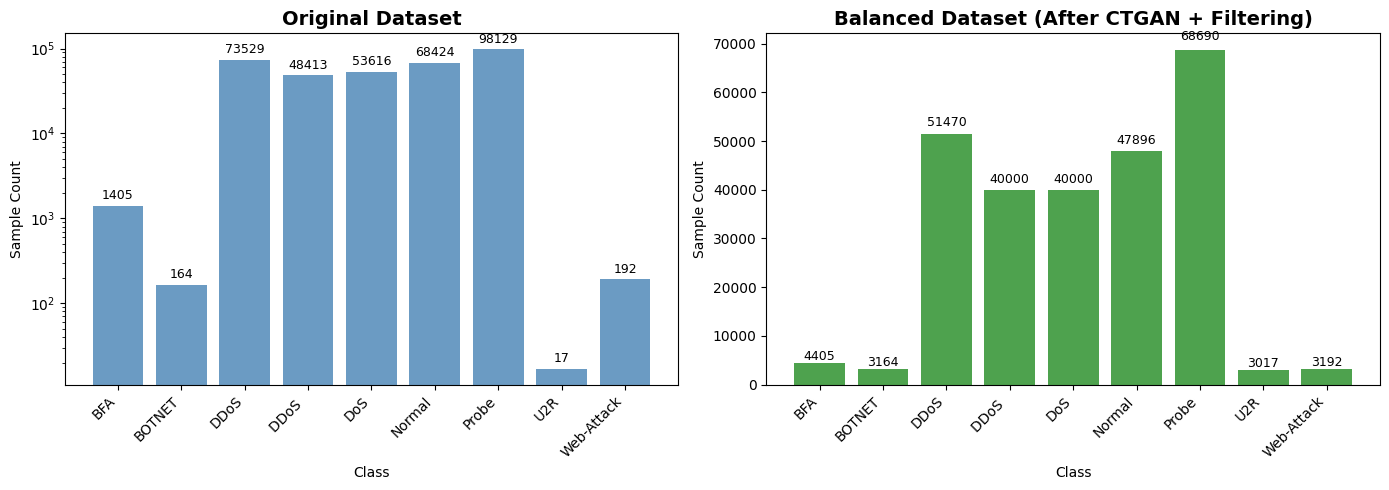

In [7]:
# Step 4: Visualize Data Balance
print("="*60)
print("STEP 4: Visualization")
print("="*60)

# Plot 1: Before vs After class distribution
print("\n📊 Class Distribution Comparison:")
fig1 = plot_data_balance(
    original_df=df_15,
    balanced_df=df_balanced,
    label_col="Label",
    save_path=f"{CTGAN_DIR}/class_balance_comparison.png"
)


📊 CTGAN Quality Scores by Class:


  Saved plot to 02ctgan/synthetic_quality_scores.png


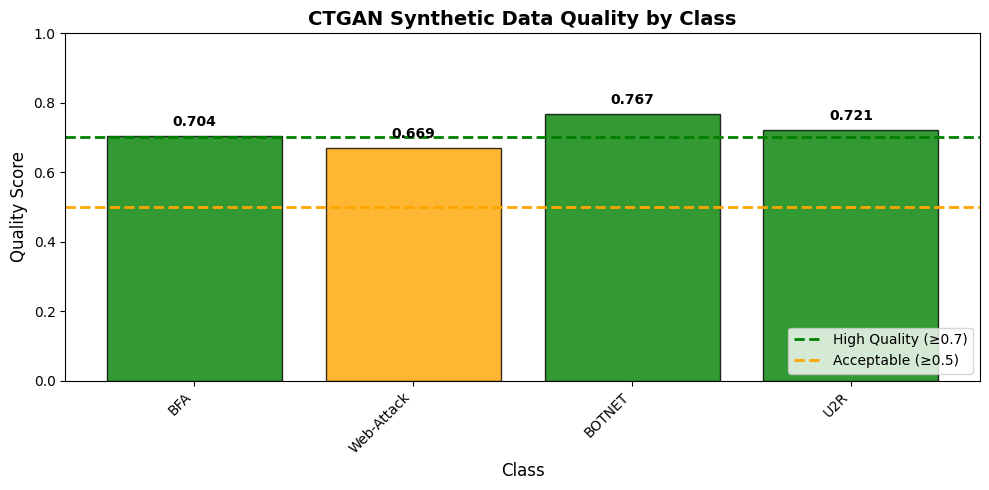

In [7]:
# Plot 2: Synthetic Data Quality Scores
print("\n📊 CTGAN Quality Scores by Class:")
fig2 = plot_synthetic_quality(
    quality_scores=quality_scores,
    save_path=f"{CTGAN_DIR}/synthetic_quality_scores.png"
)


📊 Feature Distributions: Real vs Synthetic:


  Saved plot to 02ctgan/feature_distribution_comparison.png


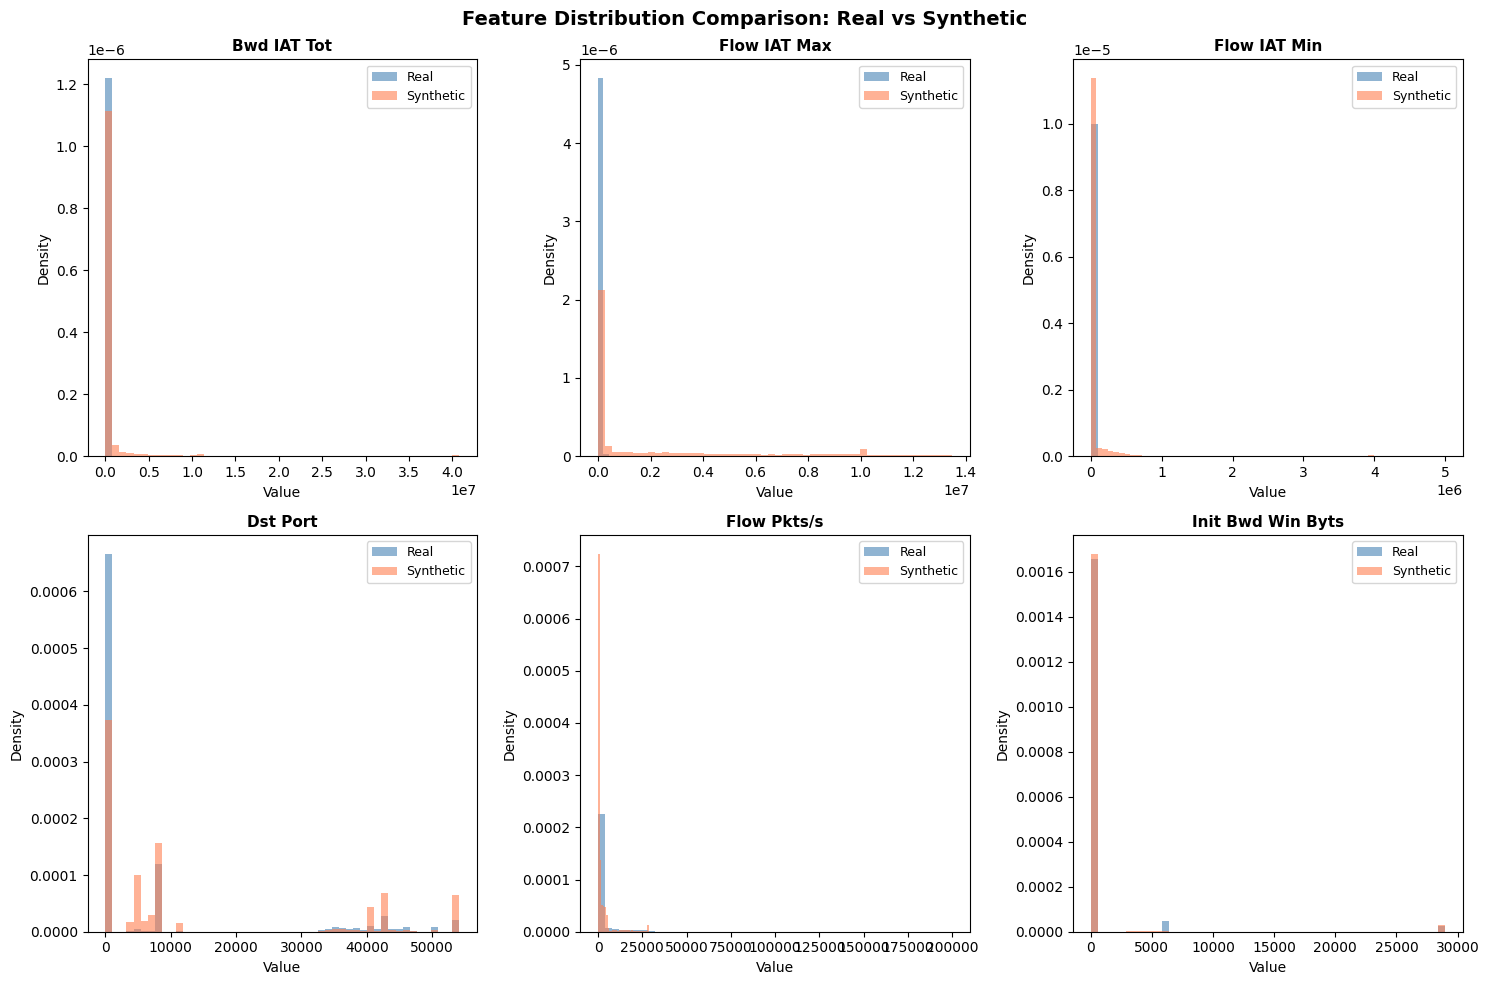

In [8]:
# Plot 3: Feature Distribution Comparison (Real vs Synthetic for minority classes)
print("\n📊 Feature Distributions: Real vs Synthetic:")

# Get only minority class data for comparison
real_minority = df_15[df_15['Label'].isin(minority_classes)]
syn_minority = df_synthetic_filtered[df_synthetic_filtered['Label'].isin(minority_classes)] if not df_synthetic_filtered.empty else pd.DataFrame()

if not syn_minority.empty:
    fig3 = plot_feature_distributions(
        real_df=real_minority,
        synthetic_df=syn_minority,
        label_col="Label",
        n_features=6,
        save_path=f"{CTGAN_DIR}/feature_distribution_comparison.png"
    )
else:
    print("  No synthetic data to compare")

In [8]:
# Part 2 Summary
print("="*60)
print("PART 2 SUMMARY: Hybrid Undersampling + CTGAN Augmentation")
print("="*60)

print("\n📊 Original Dataset:")
print(f"   Total samples: {len(df_15):,}")
print(f"   Classes: {df_15['Label'].nunique()}")
orig_dist = df_15['Label'].value_counts()
print(f"   Imbalance ratio: {orig_dist.max() / orig_dist.min():.1f}x")

print("\n🔬 Synthetic Data Generation (CTGAN):")
print(f"   Minority classes augmented: {len(minority_classes)}")
print(f"   Raw synthetic samples: {len(df_synthetic_raw):,}")
print(f"   Filtered synthetic samples: {len(df_synthetic_filtered):,}")
print(f"   Retention rate: {len(df_synthetic_filtered)/len(df_synthetic_raw)*100:.1f}%")

print("\n📉 Hybrid Undersampling:")
print(f"   After redundancy removal: {len(df_undersampled):,}")
print(f"   Reduction: {(1 - len(df_undersampled)/len(df_15))*100:.1f}%")

print("\n⚖️ Final Augmented Dataset:")
print(f"   Total samples: {len(df_balanced):,}")
bal_dist = df_balanced['Label'].value_counts()
print(f"   Imbalance ratio: {bal_dist.max() / bal_dist.min():.1f}x")
print(f"\n   Class distribution:")
for cls in sorted(bal_dist.index, key=lambda x: bal_dist[x], reverse=True):
    orig_cnt = orig_dist.get(cls, 0)
    new_cnt = bal_dist[cls]
    change = "↑" if new_cnt > orig_cnt else "↓" if new_cnt < orig_cnt else "="
    print(f"     {cls}: {new_cnt:,} ({change} from {orig_cnt:,})")

print("\n📈 Quality Scores (CTGAN):")
for cls, score in quality_scores.items():
    status = "✅" if score >= 0.7 else "⚠️" if score >= 0.5 else "❌"
    print(f"   {status} {cls}: {score:.4f}")

print(f"\n📁 Saved Files:")
for f in sorted(os.listdir(CTGAN_DIR)):
    fpath = os.path.join(CTGAN_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"   {f} ({size_mb:.2f} MB)")

PART 2 SUMMARY: Hybrid Undersampling + CTGAN Augmentation

📊 Original Dataset:
   Total samples: 343,889
   Classes: 9
   Imbalance ratio: 5772.3x

🔬 Synthetic Data Generation (CTGAN):
   Minority classes augmented: 4
   Raw synthetic samples: 20,000
   Filtered synthetic samples: 12,000
   Retention rate: 60.0%

📉 Hybrid Undersampling:
   After redundancy removal: 249,834
   Reduction: 27.4%

⚖️ Final Augmented Dataset:
   Total samples: 261,834
   Imbalance ratio: 22.8x

   Class distribution:
     Probe: 68,690 (↓ from 98,129)
     DDoS: 51,470 (↓ from 73,529)
     Normal: 47,896 (↓ from 68,424)
     DoS: 40,000 (↓ from 53,616)
     DDoS : 40,000 (↓ from 48,413)
     BFA: 4,405 (↑ from 1,405)
     Web-Attack: 3,192 (↑ from 192)
     BOTNET: 3,164 (↑ from 164)
     U2R: 3,017 (↑ from 17)

📈 Quality Scores (CTGAN):
   ✅ BFA: 0.7327
   ⚠️ Web-Attack: 0.6726
   ✅ BOTNET: 0.7354
   ✅ U2R: 0.7107

📁 Saved Files:
   augmented_15features.csv (18.38 MB)
   balanced_15features.csv (2.94 MB)
 

## End of Part 2
---
**Completed:**
- ✅ Generated 5000 synthetic samples per minority class using CTGAN
- ✅ Filtered synthetic samples to keep high-quality ones (NN distance + feature bounds)
- ✅ Undersampled majority classes using cluster-based sampling
- ✅ Created balanced dataset with ~5000 samples per class
- ✅ Visualized class distribution, quality scores, and feature distributions

**Saved to `02ctgan/`:**
- `balanced_15features.csv` - Balanced training dataset
- `class_balance_comparison.png` - Before/after distribution plot
- `synthetic_quality_scores.png` - CTGAN quality by class
- `feature_distribution_comparison.png` - Real vs synthetic features

> Load `02ctgan/balanced_15features.csv` for Part 3 model training

In [ ]:
# Training imports and setup
import os
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime
from collections import Counter

import xgboost as xgb
import cupy as cp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, confusion_matrix
)
from sklearn.neighbors import NearestNeighbors

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Training directories
XGB_DIR = "03training/xgb"
GNN_DIR = "03training/gnn"
os.makedirs(XGB_DIR, exist_ok=True)
os.makedirs(GNN_DIR, exist_ok=True)

# Load label encoder
with open("encoders/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

LABEL_MAP = {i: cls for i, cls in enumerate(label_encoder.classes_)}
BINARY_LABEL_MAP = {0: 'Benign', 1: 'Attack'}

print(f"Multiclass labels: {LABEL_MAP}")
print(f"Binary labels: {BINARY_LABEL_MAP}")

In [ ]:
# XGBoost Training Functions
def train_xgb_binary(X, y, threshold_name, feature_set_name, save_dir=XGB_DIR):
    """Train XGBoost binary classifier with GPU."""
    print(f"\n{'='*60}")
    print(f"Training XGB Binary - {feature_set_name} - {threshold_name}")
    print(f"{'='*60}")
    
    # Convert to binary labels
    y_binary = (y != label_encoder.transform(['Normal'])[0]).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=0.25, random_state=42, stratify=y_binary
    )
    
    # Convert to GPU arrays
    X_train_gpu = cp.array(X_train)
    y_train_gpu = cp.array(y_train)
    X_test_gpu = cp.array(X_test)
    
    clf = xgb.XGBClassifier(
        device="cuda",
        tree_method="hist",
        n_estimators=600,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        early_stopping_rounds=30,
        random_state=42
    )
    
    clf.fit(
        X_train_gpu, y_train_gpu,
        eval_set=[(X_train_gpu, y_train_gpu), (X_test_gpu, cp.array(y_test))],
        verbose=False
    )
    
    y_pred = cp.asnumpy(clf.predict(X_test_gpu))
    y_proba = cp.asnumpy(clf.predict_proba(X_test_gpu)[:, 1])
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    
    # Save model
    model_path = os.path.join(save_dir, f"xgb_binary_{feature_set_name}_{threshold_name}.json")
    clf.save_model(model_path)
    print(f"  ✅ Model saved: {model_path}")
    
    return {
        'model': clf,
        'threshold': threshold_name,
        'feature_set': feature_set_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'best_iteration': clf.best_iteration
    }


def train_xgb_multiclass(X, y, threshold_name, feature_set_name, save_dir=XGB_DIR):
    """Train XGBoost multiclass classifier with GPU."""
    print(f"\n{'='*60}")
    print(f"Training XGB Multiclass - {feature_set_name} - {threshold_name}")
    print(f"{'='*60}")
    
    num_classes = len(np.unique(y))
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    
    X_train_gpu = cp.array(X_train)
    y_train_gpu = cp.array(y_train)
    X_test_gpu = cp.array(X_test)
    
    clf = xgb.XGBClassifier(
        device="cuda",
        tree_method="hist",
        n_estimators=600,
        max_depth=6,
        learning_rate=0.1,
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        early_stopping_rounds=30,
        random_state=42
    )
    
    clf.fit(
        X_train_gpu, y_train_gpu,
        eval_set=[(X_train_gpu, y_train_gpu), (X_test_gpu, cp.array(y_test))],
        verbose=False
    )
    
    y_pred = cp.asnumpy(clf.predict(X_test_gpu))
    y_proba = cp.asnumpy(clf.predict_proba(X_test_gpu))
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    
    model_path = os.path.join(save_dir, f"xgb_multiclass_{feature_set_name}_{threshold_name}.json")
    clf.save_model(model_path)
    print(f"  ✅ Model saved: {model_path}")
    
    return {
        'model': clf,
        'threshold': threshold_name,
        'feature_set': feature_set_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'best_iteration': clf.best_iteration
    }

print("✅ XGBoost training functions defined")

In [ ]:
# GNN Model Classes
class GraphSAGEModel(nn.Module):
    def __init__(self, num_features, hidden_dim=128, num_classes=8, dropout=0.3, num_layers=2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(num_features, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.lin = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x, edge_index):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(x)


class GATModel(nn.Module):
    def __init__(self, num_features, hidden_dim=128, num_classes=8, dropout=0.3, num_layers=2, heads=4):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(num_features, hidden_dim, heads=heads, dropout=dropout))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim * heads, hidden_dim, heads=heads, dropout=dropout))
        if num_layers > 1:
            self.convs.append(GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=dropout))
        self.lin = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x, edge_index):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(x)


def build_knn_graph(X, protocols, k=5):
    """Build protocol-aware k-NN graph."""
    n_samples = X.shape[0]
    
    def get_protocol_group(p):
        try:
            p = int(p)
            if p == 6: return 'TCP'
            elif p == 17: return 'UDP'
            elif p == 1: return 'ICMP'
            else: return 'Other'
        except:
            return 'Other'
    
    protocol_groups = np.array([get_protocol_group(p) for p in protocols])
    unique_groups = np.unique(protocol_groups)
    
    all_edges = []
    for group in unique_groups:
        group_mask = protocol_groups == group
        group_indices = np.where(group_mask)[0]
        n_group = len(group_indices)
        
        if n_group < 2:
            continue
        
        X_group = X[group_indices]
        k_actual = min(k, n_group - 1)
        
        knn = NearestNeighbors(n_neighbors=k_actual + 1, metric='euclidean', n_jobs=-1)
        knn.fit(X_group)
        _, indices = knn.kneighbors(X_group)
        
        for local_i in range(n_group):
            global_i = group_indices[local_i]
            for j in range(1, k_actual + 1):
                local_j = indices[local_i, j]
                global_j = group_indices[local_j]
                all_edges.append([global_i, global_j])
    
    return torch.tensor(all_edges, dtype=torch.long).t().contiguous()


def train_gnn(model, data, epochs=200, patience=30, lr=0.005):
    """Train GNN with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    
    # Class weights for imbalanced data
    class_counts = Counter(data.y[data.train_mask].cpu().numpy())
    total = sum(class_counts.values())
    num_classes = len(class_counts)
    weights = torch.zeros(max(class_counts.keys()) + 1, device=device)
    for cls, count in class_counts.items():
        weights[cls] = total / (num_classes * count)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(data.x, data.edge_index)
            val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask]).item()
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if epoch % 20 == 0:
            print(f"    Epoch {epoch}: Train Loss={loss.item():.4f}, Val Loss={val_loss:.4f}")
        
        if patience_counter >= patience:
            print(f"    Early stopping at epoch {epoch}")
            break
    
    model.load_state_dict(best_model_state)
    return model


def evaluate_gnn(model, data, mask):
    """Evaluate GNN on given mask."""
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        
        y_pred = pred[mask].cpu().numpy()
        y_true = data.y[mask].cpu().numpy()
        
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print("✅ GNN model classes and functions defined")

In [ ]:
# Complete GNN Training Pipeline
def train_gnn_pipeline(
    df,
    feature_set_name,
    split_name,
    train_ratio,
    val_ratio,
    model_type='GAT',
    binary=False,
    save_dir=GNN_DIR
):
    """
    Complete GNN training pipeline.
    
    Args:
        df: DataFrame with features + Label
        feature_set_name: e.g., '15features'
        split_name: e.g., '50_25_25'
        train_ratio, val_ratio: Split ratios
        model_type: 'GAT' or 'GraphSAGE'
        binary: If True, train binary classifier
        save_dir: Save directory
    """
    task = 'binary' if binary else 'multiclass'
    print(f"\n{'='*70}")
    print(f"Training GNN {model_type} - {task} - {feature_set_name} - Split {split_name}")
    print(f"{'='*70}")
    
    # Prepare data
    X = df.drop(columns=['Label']).values
    
    if binary:
        normal_idx = label_encoder.transform(['Normal'])[0]
        y = (label_encoder.transform(df['Label']) != normal_idx).astype(int)
        num_classes = 2
    else:
        y = label_encoder.transform(df['Label'])
        num_classes = len(label_encoder.classes_)
    
    # Extract protocol for graph construction
    if 'Protocol' in df.columns:
        protocols = df['Protocol'].values
    else:
        protocols = np.full(len(df), 6)  # Default TCP
    
    # Scale features
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_samples = X.shape[0]
    num_features = X.shape[1]
    
    print(f"  Data: {n_samples} samples, {num_features} features, {num_classes} classes")
    
    # Build graph
    print(f"  Building k-NN graph...")
    edge_index = build_knn_graph(X_scaled, protocols, k=5)
    edge_index = edge_index.to(device)
    print(f"  Graph: {edge_index.shape[1]} edges")
    
    # Create train/val/test split
    idx = np.arange(n_samples)
    test_ratio = 1.0 - train_ratio - val_ratio
    
    train_idx, temp_idx = train_test_split(idx, test_size=(val_ratio + test_ratio), 
                                            random_state=42, stratify=y)
    val_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx = train_test_split(temp_idx, test_size=(1 - val_relative),
                                          random_state=42, stratify=y[temp_idx])
    
    train_mask = torch.zeros(n_samples, dtype=torch.bool)
    val_mask = torch.zeros(n_samples, dtype=torch.bool)
    test_mask = torch.zeros(n_samples, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    print(f"  Split: Train={train_mask.sum().item()}, Val={val_mask.sum().item()}, Test={test_mask.sum().item()}")
    
    # Create PyG data object
    data = Data(
        x=torch.FloatTensor(X_scaled).to(device),
        edge_index=edge_index,
        y=torch.LongTensor(y).to(device),
        train_mask=train_mask.to(device),
        val_mask=val_mask.to(device),
        test_mask=test_mask.to(device)
    )
    
    # Create model
    if model_type == 'GAT':
        model = GATModel(num_features, hidden_dim=128, num_classes=num_classes, dropout=0.3)
    else:
        model = GraphSAGEModel(num_features, hidden_dim=128, num_classes=num_classes, dropout=0.3)
    model = model.to(device)
    
    print(f"  Training {model_type}...")
    model = train_gnn(model, data, epochs=200, patience=30)
    
    # Evaluate
    test_metrics = evaluate_gnn(model, data, data.test_mask)
    print(f"\n  Test Results:")
    print(f"    Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"    Precision: {test_metrics['precision']:.4f}")
    print(f"    Recall:    {test_metrics['recall']:.4f}")
    print(f"    F1:        {test_metrics['f1']:.4f}")
    
    # Save model
    model_name = f"gnn_{model_type.lower()}_{task}_{feature_set_name}_{split_name}.pt"
    model_path = os.path.join(save_dir, model_name)
    
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'model_type': model_type,
        'task': task,
        'feature_set': feature_set_name,
        'split': split_name,
        'num_features': num_features,
        'num_classes': num_classes,
        'test_metrics': test_metrics
    }
    torch.save(checkpoint, model_path)
    print(f"  ✅ Model saved: {model_path}")
    
    # Save scaler
    scaler_path = os.path.join(save_dir, f"scaler_{task}_{feature_set_name}_{split_name}.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    
    return {
        'model_type': model_type,
        'task': task,
        'feature_set': feature_set_name,
        'split': split_name,
        **test_metrics
    }

print("✅ GNN training pipeline defined")

### 3.1 XGBoost Training
Train XGBoost models at different threshold levels (20/50/80) for both feature sets.

In [ ]:
# Load datasets for training
# Use augmented data from CTGAN if available, otherwise use original
def load_training_data(feature_count):
    """Load training data, preferring augmented if available."""
    aug_path = f"02ctgan/augmented_{feature_count}features.csv"
    orig_path = f"01eda/cleaned_data{feature_count}.csv"
    
    if os.path.exists(aug_path):
        df = pd.read_csv(aug_path)
        print(f"Loaded augmented data: {aug_path} ({df.shape})")
    else:
        df = pd.read_csv(orig_path)
        print(f"Loaded original data: {orig_path} ({df.shape})")
    return df

# Check what data files exist
print("Available data files:")
for f in os.listdir("01eda"):
    if f.endswith('.csv'):
        print(f"  01eda/{f}")
        
if os.path.exists("02ctgan"):
    for f in os.listdir("02ctgan"):
        if f.endswith('.csv'):
            print(f"  02ctgan/{f}")

In [ ]:
# Train XGBoost models
xgb_results = []

# Thresholds for testing different percentages of data
thresholds = [('20', 0.2), ('50', 0.5), ('80', 0.8)]

# Feature sets to train on
feature_sets = [15, 52]

for n_features in feature_sets:
    df = load_training_data(n_features)
    
    # Prepare X and y
    X = df.drop(columns=['Label']).values
    y = label_encoder.transform(df['Label'])
    
    for threshold_name, threshold in thresholds:
        # Subsample data for different thresholds
        if threshold < 1.0:
            X_subset, _, y_subset, _ = train_test_split(
                X, y, train_size=threshold, random_state=42, stratify=y
            )
        else:
            X_subset, y_subset = X, y
        
        # Binary classification
        result_binary = train_xgb_binary(
            X_subset, y_subset, 
            threshold_name=threshold_name,
            feature_set_name=f"{n_features}features"
        )
        xgb_results.append(result_binary)
        
        # Multiclass classification  
        result_multi = train_xgb_multiclass(
            X_subset, y_subset,
            threshold_name=threshold_name,
            feature_set_name=f"{n_features}features"
        )
        xgb_results.append(result_multi)

# Create results summary
xgb_summary = pd.DataFrame([{
    'Model': 'XGBoost',
    'Task': 'binary' if 'binary' in r.get('feature_set', '') or r.get('accuracy', 0) > 0.95 else 'multiclass',
    'Features': r['feature_set'],
    'Threshold': r['threshold'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1': r['f1'],
    'AUC': r['auc']
} for r in xgb_results])

# Save summary
xgb_summary.to_csv(f"{XGB_DIR}/xgb_results_summary.csv", index=False)
print("\n📊 XGBoost Results Summary:")
display(xgb_summary)

### 3.2 GNN Training
Train GAT and GraphSAGE models with different train/val/test splits for both binary and multiclass classification.

In [ ]:
# Train GNN models
gnn_results = []

# Splits to train on
splits = [
    ('50_25_25', 0.50, 0.25),
    ('70_15_15', 0.70, 0.15),
    ('20_40_40', 0.20, 0.40)
]

# Model types
model_types = ['GAT', 'GraphSAGE']

# Feature sets (use smaller samples for GNN due to memory)
# Limit to ~100k samples max for GPU memory
MAX_GNN_SAMPLES = 100000

for n_features in feature_sets:
    df = load_training_data(n_features)
    
    # Subsample if too large
    if len(df) > MAX_GNN_SAMPLES:
        df = df.sample(n=MAX_GNN_SAMPLES, random_state=42)
        print(f"  Subsampled to {MAX_GNN_SAMPLES} for GNN training")
    
    for model_type in model_types:
        for split_name, train_ratio, val_ratio in splits:
            # Binary classification
            result_binary = train_gnn_pipeline(
                df,
                feature_set_name=f"{n_features}features",
                split_name=split_name,
                train_ratio=train_ratio,
                val_ratio=val_ratio,
                model_type=model_type,
                binary=True
            )
            gnn_results.append(result_binary)
            
            # Clear GPU cache
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            
            # Multiclass classification
            result_multi = train_gnn_pipeline(
                df,
                feature_set_name=f"{n_features}features",
                split_name=split_name,
                train_ratio=train_ratio,
                val_ratio=val_ratio,
                model_type=model_type,
                binary=False
            )
            gnn_results.append(result_multi)
            
            # Clear GPU cache
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

# Create results summary
gnn_summary = pd.DataFrame(gnn_results)
gnn_summary.to_csv(f"{GNN_DIR}/gnn_results_summary.csv", index=False)
print("\n📊 GNN Results Summary:")
display(gnn_summary)

### 3.3 Combined Results Comparison
Generate comparison tables for all trained models.

In [ ]:
# Generate combined comparison table
import matplotlib.pyplot as plt
import seaborn as sns

# Load results if not in memory
if 'xgb_summary' not in dir():
    xgb_summary = pd.read_csv(f"{XGB_DIR}/xgb_results_summary.csv")
if 'gnn_summary' not in dir():
    gnn_summary = pd.read_csv(f"{GNN_DIR}/gnn_results_summary.csv")

# Combine results
all_results = []

# XGBoost results
for _, row in xgb_summary.iterrows():
    all_results.append({
        'Model': 'XGBoost',
        'Architecture': 'XGBoost',
        'Task': row['Task'],
        'Features': row['Features'],
        'Split/Threshold': row['Threshold'],
        'Accuracy': row['Accuracy'],
        'Precision': row['Precision'],
        'Recall': row['Recall'],
        'F1': row['F1']
    })

# GNN results
for _, row in gnn_summary.iterrows():
    all_results.append({
        'Model': 'GNN',
        'Architecture': row['model_type'],
        'Task': row['task'],
        'Features': row['feature_set'],
        'Split/Threshold': row['split'],
        'Accuracy': row['accuracy'],
        'Precision': row['precision'],
        'Recall': row['recall'],
        'F1': row['f1']
    })

combined_df = pd.DataFrame(all_results)

# Save combined results
combined_df.to_csv("03training/combined_results.csv", index=False)

# Display tables by task
print("\n" + "="*80)
print("BINARY CLASSIFICATION RESULTS")
print("="*80)
binary_df = combined_df[combined_df['Task'] == 'binary'].sort_values('F1', ascending=False)
display(binary_df)

print("\n" + "="*80)
print("MULTICLASS CLASSIFICATION RESULTS")
print("="*80)
multi_df = combined_df[combined_df['Task'] == 'multiclass'].sort_values('F1', ascending=False)
display(multi_df)

# Best models
print("\n" + "="*80)
print("BEST MODELS")
print("="*80)
print(f"\n🏆 Best Binary Model:")
best_binary = binary_df.iloc[0]
print(f"   {best_binary['Architecture']} ({best_binary['Features']}, {best_binary['Split/Threshold']})")
print(f"   Accuracy: {best_binary['Accuracy']:.4f}, F1: {best_binary['F1']:.4f}")

print(f"\n🏆 Best Multiclass Model:")
best_multi = multi_df.iloc[0]
print(f"   {best_multi['Architecture']} ({best_multi['Features']}, {best_multi['Split/Threshold']})")
print(f"   Accuracy: {best_multi['Accuracy']:.4f}, F1: {best_multi['F1']:.4f}")

In [ ]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Binary - F1 comparison
ax1 = axes[0, 0]
binary_pivot = binary_df.pivot_table(
    values='F1', 
    index='Architecture', 
    columns='Features', 
    aggfunc='max'
)
binary_pivot.plot(kind='bar', ax=ax1)
ax1.set_title('Binary Classification - Best F1 by Architecture')
ax1.set_ylabel('F1 Score')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title='Features')

# Multiclass - F1 comparison
ax2 = axes[0, 1]
multi_pivot = multi_df.pivot_table(
    values='F1', 
    index='Architecture', 
    columns='Features', 
    aggfunc='max'
)
multi_pivot.plot(kind='bar', ax=ax2)
ax2.set_title('Multiclass Classification - Best F1 by Architecture')
ax2.set_ylabel('F1 Score')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Features')

# GNN Split comparison - Binary
ax3 = axes[1, 0]
gnn_binary = gnn_summary[gnn_summary['task'] == 'binary']
gnn_binary_pivot = gnn_binary.pivot_table(
    values='f1', 
    index='model_type', 
    columns='split', 
    aggfunc='max'
)
gnn_binary_pivot.plot(kind='bar', ax=ax3)
ax3.set_title('GNN Binary - F1 by Split')
ax3.set_ylabel('F1 Score')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(title='Split')

# GNN Split comparison - Multiclass
ax4 = axes[1, 1]
gnn_multi = gnn_summary[gnn_summary['task'] == 'multiclass']
gnn_multi_pivot = gnn_multi.pivot_table(
    values='f1', 
    index='model_type', 
    columns='split', 
    aggfunc='max'
)
gnn_multi_pivot.plot(kind='bar', ax=ax4)
ax4.set_title('GNN Multiclass - F1 by Split')
ax4.set_ylabel('F1 Score')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(title='Split')

plt.tight_layout()
plt.savefig("03training/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to 03training/model_comparison.png")

## Training Complete
---
All models have been trained and saved to:
- XGBoost: `03training/xgb/`
- GNN: `03training/gnn/`
- Summary: `03training/combined_results.csv`

### Model Count Summary:
- **XGBoost**: 12 models (2 tasks × 2 feature sets × 3 thresholds)
- **GNN GAT**: 12 models (2 tasks × 2 feature sets × 3 splits)
- **GNN GraphSAGE**: 12 models (2 tasks × 2 feature sets × 3 splits)
- **Total**: 36 models (or 24 if only using the best GNN architecture)